# Color Quantization

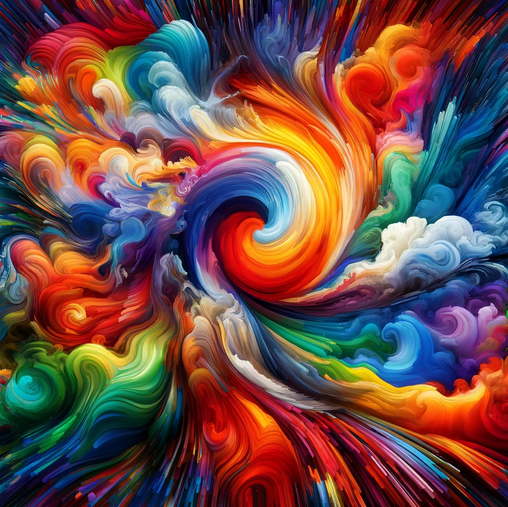

## Introduction
A standard color image of size $n \times m$ is represented by $n \cdot m \cdot 3$ integers from the range $[0, 255]$. This gives a total of over 16 million possible colors. Color quantization consists in drastically reducing the number of used colors in order to reduce file size, while preserving image quality as best as possible.
The simplest quantization method is using the $k$-means method. It works great for color reduction, but its nature also affects the final appearance of the image:


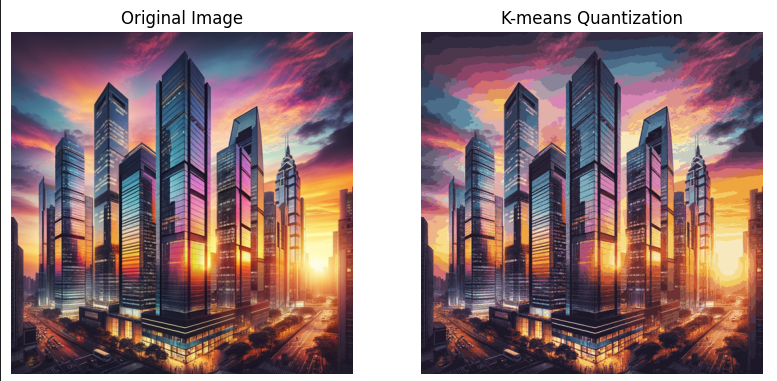


The [$k$-means](https://en.wikipedia.org/wiki/K-means_clustering) method quantizes the image by minimizing the mean squared error ([MSE](https://en.wikipedia.org/wiki/Mean_squared_error)) between the original and reconstructed image. 
However, it doesn't care at all which colors it will ultimately use. It turns out that if we impose costs of using colors, we will be able to influence the quality of quantization. However, the $k$-means method will no longer be optimal.

Changing the quantization method can therefore affect the final quality of the quantized image. And that's what the task below is about.


## Task

The goal of the task is to write a clustering algorithm that minimizes a different objective function than $k$-means.
First, let's define *color cost*. We understand an RGB color as a three-dimensional vector from the set $[0,1,...,255]^3$, and the cost of color $c$ is defined as
the Euclidean distance to the nearest "simple" color in RGB space, where simple colors are: black $(0,0,0)$, white $(255,255,255)$, red $(255,0,0)$, green $(0,255,0)$, blue $(0,0,255)$, yellow $(255,255,0)$, magenta $(255,0,255)$ and cyan $(0,255,255)$. Details can be found in the `color_cost` function.
With this defined cost function, the most expensive color is $(127,127,127)$, i.e., gray. 
The interpretation of this cost function is that we will want to force the quantization algorithm to prefer colors that are more vivid and lively.

Our objective function will be a weighted sum of individual components:
1. `MSE`: mean squared error between the original and reconstructed image --- this component ensures that the quantized image is close to the original.
2. `max_color_cost`: the largest cost of used colors --- this component enhances color vividness by controlling the least vivid color.
3. `mean_color_cost`: average color cost calculated over all pixels --- this component forces used colors to be appropriately vivid on average.

The final quality criterion for quantization will be $$2\cdot MSE  + 21\cdot max\_color\_cost + 42\cdot mean\_color\_cost.$$

The above criterion and all functions mentioned above are implemented by us below. 

In the task, we assume that the number of colors is predetermined and equals $37$. Your algorithm should therefore quantize the image to $37$ colors in such a way as to minimize the above objective function.


## Constraints
- In this task, you can use a GPU.
- Your function should return 5 quantized images in at most 3 minutes using Google Colab with GPU.
- Both the original and quantized image should be provided to the evaluation function as `np.array` of type `np.uint8` with values from the range $[0, 255]$.

## Notes and hints
- Each image is an individual training set; during evaluation, no weights of models trained by you will be loaded.
- You will be working on images generated by DALL-E and Stable Diffusion.
- In the `your_quantization_algorithm` function, a seed should be set so that results obtained on the training and validation sets transfer to the test set.

## Submission files
Only this notebook.

## Evaluation
Remember that during grading, the `FINAL_EVALUATION_MODE` flag will be set to `True`. Using the `evaluation_script.py` script, you will be able to ensure that your solution executes correctly on our evaluation servers. 

For this task, you can earn between 0 and 1.5 points. If you get a score above 8900, you will get 0, and if below 8000, you will get 1.5 points. Between these values, your score decreases linearly with the score value.

# Starter code

In [ ]:
######################### DO NOT CHANGE THIS CELL DURING SUBMISSION ##########################
FINAL_EVALUATION_MODE = False
# During grading of your solution, we will change this value to True
# The value of this flag M U S T be set to False in the solution you submit to us!

In [ ]:
######################### DO NOT CHANGE THIS CELL ##########################
import os
import numpy as np
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import typing

import glob

## Loading data

In [ ]:
######################### DO NOT CHANGE THIS CELL ##########################

# A class that makes it easier to load images from a given folder
class ImageDataset:
    def __init__(self, image_dir: str):
        self.filelist = glob.glob(image_dir + "/*.jpg")
        self.IMAGE_DIMS = (512, 512)

    def __len__(self):
        return len(self.filelist)

    def __getitem__(self, idx) -> np.ndarray:
        with Image.open(self.filelist[idx]) as image:
            image = image.convert('RGB')
            image = image.resize(self.IMAGE_DIMS)
            return np.array(image)

    def __iter__(self) -> typing.Iterator[np.ndarray]:
        return (self[i] for i in range(len(self.filelist)))

## Code with evaluation criterion

In [ ]:
######################### DO NOT CHANGE THIS CELL ##########################

# Below you will find definitions of MSE and color usage cost
# Remember to calculate them in RGB space, i.e., on integer values from the range [0, 255]
# Scaling is allowed only during training!

# Let's define the quantization quality evaluation criterion
# We will use the mean squared error (MSE) for this
def mse(img, img_quant):
  return ((img_quant.astype(np.float32) - img.astype(np.float32))**2).mean()


# Next, let's define the cost of using colors
# The closer a color is to "simple" colors, the lower its usage cost
def color_cost(img_quant):
    vertices = np.array([
        [0, 0, 0], [0, 0, 255], [0, 255, 0], [0, 255, 255],
        [255, 0, 0], [255, 0, 255], [255, 255, 0], [255, 255, 255]
    ])
    
    pixels = img_quant.reshape(-1,3)
    
    differences = pixels[:, np.newaxis, :] - vertices[np.newaxis, :, :]
    squared_distances = np.sum(differences**2, axis=2)
    costs = np.sqrt(np.min(squared_distances, axis=1))

    return np.mean(costs), np.max(costs)


# The total criterion defined in the task description
def quantization_score(img, img_quant):
    assert img.dtype == np.uint8
    assert img_quant.dtype == np.uint8
    assert len(np.unique(img_quant.reshape(-1,3), axis=0)) == 37
       
    mse_cost = mse(img, img_quant)
    mean_color_cost, max_color_cost = color_cost(img_quant)
    score = mse_cost * 2 + max_color_cost * 21 + mean_color_cost * 42
    print(f'MSE: {mse_cost:.4f}, max_color_cost: {max_color_cost:.4f}, mean_color_cost: {mean_color_cost:.4f}')
    print(f'Score: {score:.4f}')
    return score

# Your solution

This section is the place for your solution. You should only make changes here!

In [ ]:
def your_quantization_algorithm(img):
    #TODO - below is presented an implementation of the k-means quantization algorithm worth 0 points
    #TODO - implement your own quantization algorithm
    from sklearn.cluster import KMeans
    
    pixels = img.reshape(-1, 3)
    kmeans = KMeans(n_clusters=37, random_state=0).fit(pixels)
    colors = kmeans.cluster_centers_
    labels = kmeans.predict(pixels)
    quantized_image = colors[labels].reshape(img.shape)
    return quantized_image.astype(np.uint8)

# Evaluation

The code below will be used to evaluate the solution. After submitting your solution to us, the function `evaluate_algorithm(your_quantization_algorithm, 'test_data')` will be executed, i.e., almost identical code to the one below will run on the `test_data` image directory available only to the task graders.

Before submitting, make sure that the entire notebook executes from start to finish without errors and without user intervention after running `Run All`.

In [ ]:
# Display a comparison of the original and quantized image
def show_quantization_results(original, quantized):
        _, ax = plt.subplots(1, 2, figsize=(8, 4))
        ax[0].imshow(original)
        ax[0].set_title("Original")
        ax[0].axis("off")

        ax[1].imshow(quantized)
        ax[1].set_title("Quantization result")
        ax[1].axis("off")
        plt.show()

In [ ]:
def evaluate_algorithm(quantization_algorithm, data_dir):
    dataset = ImageDataset(data_dir)
    scores = []
    for image in dataset:
        quantized_image = quantization_algorithm(image)
        show_quantization_results(image, quantized_image)
        score = quantization_score(image, quantized_image)
        scores.append(score)
    return np.mean(scores)

In [ ]:
if not FINAL_EVALUATION_MODE:
    print(f"Final score: {evaluate_algorithm(your_quantization_algorithm, 'valid_data'):.4f}")